# AeroML Forward Model v3

This notebook is the next refinement pass after `Forward v2`.

## Why v3 exists
`Forward v2` showed that broad target-aware weighting was too blunt:

- training was stable
- but overall performance regressed against `Forward Baseline v1`
- the main remaining weak spot is still low-drag `CdMin`

## v3 strategy
Keep the same XFOIL-only data policy, same fingerprint split, and same MLP family,
but make the weighting much narrower:

- only target `CdMin`
- especially low-drag cases
- and optionally the hardest regime, `Mach = 0.50`

## Workflow
1. Train several small `CdMin`-focused variants on one seed
2. Pick the best variant by validation `CdMin` behavior
3. Rerun that winning variant across 3 seeds
4. Build an ensemble and compare against baseline v1
5. Report the inverse-design gate again


In [1]:
from pathlib import Path
import shutil

SRC = Path("/kaggle/input/notebooks/sanidhyavijay24/aeroml-single-source-mlp")  # change this
DST = Path("/kaggle/working")

files = [
    "aeroml_xfoil_n9_dataset.npz",
    "aeroml_xfoil_n9_meta.csv",
    "aeroml_xfoil_split_manifest.csv",
    "aeroml_xfoil_forward_v1_predictions.csv",
    "aeroml_xfoil_forward_v1_metrics.json",
    "aeroml_xfoil_forward_v1_model.keras",
    "aeroml_xfoil_forward_v1_artifacts.pkl",
]

for name in files:
    src = SRC / name
    dst = DST / name
    if src.exists():
        shutil.copy2(src, dst)
        print("Copied", name)
    else:
        print("Missing", name)


Copied aeroml_xfoil_n9_dataset.npz
Copied aeroml_xfoil_n9_meta.csv
Copied aeroml_xfoil_split_manifest.csv
Copied aeroml_xfoil_forward_v1_predictions.csv
Copied aeroml_xfoil_forward_v1_metrics.json
Copied aeroml_xfoil_forward_v1_model.keras
Copied aeroml_xfoil_forward_v1_artifacts.pkl


In [2]:
from pathlib import Path

COMMON_MODULE_TEXT = 'import hashlib\nimport json\nimport math\nimport os\nimport pickle\nimport warnings\nfrom pathlib import Path\n\nimport numpy as np\nimport pandas as pd\nfrom sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score\nfrom sklearn.model_selection import GroupShuffleSplit\nfrom sklearn.preprocessing import StandardScaler\nfrom tqdm.auto import tqdm\n\nwarnings.filterwarnings("ignore")\n\nSOURCE_NAME = "XFOIL ncrit=9"\nN_STATIONS = 160\nFINGERPRINT_DECIMALS = 5\nRANDOM_STATE = 42\n\nWORK_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()\nCACHE_DATA_PATH = WORK_DIR / "aeroml_xfoil_n9_dataset.npz"\nCACHE_META_PATH = WORK_DIR / "aeroml_xfoil_n9_meta.csv"\nSPLIT_MANIFEST_PATH = WORK_DIR / "aeroml_xfoil_split_manifest.csv"\n\n\ndef discover_data_dir():\n    explicit = os.environ.get("AEROML_DATA_DIR")\n    if explicit and Path(explicit).exists():\n        return Path(explicit)\n\n    search_roots = [Path("/kaggle/input"), Path.cwd()]\n    candidates = []\n\n    for root in search_roots:\n        if not root.exists():\n            continue\n\n        for path in root.rglob("*"):\n            if not path.is_dir():\n                continue\n\n            dat_count = len(list(path.glob("*.dat")))\n            if dat_count < 100:\n                continue\n\n            pkl_count = len(list(path.glob("*.pkl")))\n            if dat_count == pkl_count and pkl_count > 0:\n                candidates.append((dat_count, path))\n\n    if not candidates:\n        raise FileNotFoundError(\n            "Could not auto-discover the AeroML dataset. "\n            "Set AEROML_DATA_DIR manually if needed."\n        )\n\n    candidates.sort(key=lambda item: (-item[0], len(str(item[1]))))\n    return candidates[0][1]\n\n\nDATA_DIR = discover_data_dir()\n\n\ndef read_dat_file(path):\n    coords = []\n    with open(path, "r", encoding="utf-8", errors="ignore") as handle:\n        for line in handle:\n            parts = line.strip().split()\n            if len(parts) != 2:\n                continue\n            try:\n                coords.append((float(parts[0]), float(parts[1])))\n            except ValueError:\n                continue\n\n    coords = np.asarray(coords, dtype=np.float64)\n    if len(coords) < 20:\n        return None\n\n    keep = np.ones(len(coords), dtype=bool)\n    keep[1:] = np.any(np.abs(np.diff(coords, axis=0)) > 1e-12, axis=1)\n    coords = coords[keep]\n    return coords if len(coords) >= 20 else None\n\n\ndef normalize_coords(coords):\n    coords = np.asarray(coords, dtype=np.float64).copy()\n    x_min = coords[:, 0].min()\n    x_max = coords[:, 0].max()\n    chord = x_max - x_min\n    if chord <= 1e-8:\n        return None\n\n    coords[:, 0] = (coords[:, 0] - x_min) / chord\n    coords[:, 1] = coords[:, 1] / chord\n    return coords\n\n\ndef split_upper_lower(coords):\n    le_idx = int(np.argmin(coords[:, 0]))\n    upper = coords[: le_idx + 1]\n    lower = coords[le_idx:]\n\n    if len(upper) < 5 or len(lower) < 5:\n        return None, None\n\n    if upper[0, 0] < upper[-1, 0]:\n        upper = upper[::-1]\n    if lower[0, 0] > lower[-1, 0]:\n        lower = lower[::-1]\n\n    return upper, lower\n\n\ndef prepare_surface_for_interp(surface):\n    surface = np.asarray(surface, dtype=np.float64)\n    order = np.argsort(surface[:, 0])\n    surface = surface[order]\n\n    rounded_x = np.round(surface[:, 0], 10)\n    _, unique_idx = np.unique(rounded_x, return_index=True)\n    surface = surface[np.sort(unique_idx)]\n    return surface if len(surface) >= 5 else None\n\n\ndef cosine_spacing(n_stations):\n    beta = np.linspace(0.0, np.pi, n_stations)\n    return 0.5 * (1.0 - np.cos(beta))\n\n\ndef estimate_le_radius(x_grid, thickness):\n    nose_x = x_grid[1:6]\n    nose_t = thickness[1:6]\n    radius = 0.5 * (nose_t ** 2) / np.clip(nose_x, 1e-6, None)\n    return float(np.median(radius))\n\n\ndef geometry_representation(dat_path, n_stations=N_STATIONS):\n    coords = read_dat_file(dat_path)\n    if coords is None:\n        return None\n\n    coords = normalize_coords(coords)\n    if coords is None:\n        return None\n\n    upper, lower = split_upper_lower(coords)\n    if upper is None or lower is None:\n        return None\n\n    upper = prepare_surface_for_interp(upper)\n    lower = prepare_surface_for_interp(lower)\n    if upper is None or lower is None:\n        return None\n\n    x_grid = cosine_spacing(n_stations)\n    y_upper = np.interp(x_grid, upper[:, 0], upper[:, 1])\n    y_lower = np.interp(x_grid, lower[:, 0], lower[:, 1])\n\n    thickness = y_upper - y_lower\n    camber = 0.5 * (y_upper + y_lower)\n    dyu_dx = np.gradient(y_upper, x_grid)\n    dyl_dx = np.gradient(y_lower, x_grid)\n\n    curv_upper = np.gradient(dyu_dx, x_grid) / np.maximum((1.0 + dyu_dx**2) ** 1.5, 1e-6)\n    curv_lower = np.gradient(dyl_dx, x_grid) / np.maximum((1.0 + dyl_dx**2) ** 1.5, 1e-6)\n\n    max_t_idx = int(np.argmax(thickness))\n    max_c_idx = int(np.argmax(np.abs(camber)))\n\n    scalar_features = np.array(\n        [\n            thickness[max_t_idx],\n            x_grid[max_t_idx],\n            camber[max_c_idx],\n            x_grid[max_c_idx],\n            np.max(camber),\n            np.min(camber),\n            estimate_le_radius(x_grid, thickness),\n            thickness[-1],\n            math.degrees(math.atan(dyu_dx[-1]) - math.atan(dyl_dx[-1])),\n            np.trapz(thickness, x_grid),\n            np.sum(np.sqrt(np.diff(x_grid) ** 2 + np.diff(y_upper) ** 2)),\n            np.sum(np.sqrt(np.diff(x_grid) ** 2 + np.diff(y_lower) ** 2)),\n            np.mean(np.abs(curv_upper)),\n            np.mean(np.abs(curv_lower)),\n            np.max(np.abs(curv_upper)),\n            np.max(np.abs(curv_lower)),\n        ],\n        dtype=np.float32,\n    )\n\n    profile_features = np.concatenate([thickness, camber, dyu_dx, dyl_dx], axis=0).astype(np.float32)\n    fingerprint_payload = np.round(np.concatenate([y_upper, y_lower]), FINGERPRINT_DECIMALS).astype(np.float32)\n    fingerprint = hashlib.sha1(fingerprint_payload.tobytes()).hexdigest()\n\n    return {\n        "profile": profile_features,\n        "scalar": scalar_features,\n        "fingerprint": fingerprint,\n    }\n\n\ndef build_flow_features(re_value, mach_value):\n    re_value = float(re_value)\n    mach_value = float(mach_value)\n    return np.array(\n        [\n            np.log10(re_value),\n            mach_value,\n            mach_value**2,\n            1.0 / np.sqrt(re_value),\n            1.0 / np.sqrt(max(1.0 - mach_value**2, 1e-6)),\n        ],\n        dtype=np.float32,\n    )\n\n\ndef build_or_load_cached_dataset():\n    if CACHE_DATA_PATH.exists() and CACHE_META_PATH.exists():\n        cached = np.load(CACHE_DATA_PATH, allow_pickle=True)\n        meta = pd.read_csv(CACHE_META_PATH)\n        return (\n            cached["X_profile"].astype(np.float32),\n            cached["X_scalar"].astype(np.float32),\n            cached["X_flow"].astype(np.float32),\n            cached["y_targets"].astype(np.float32),\n            meta,\n        )\n\n    dat_paths = sorted(DATA_DIR.glob("*.dat"))\n    geom_by_fp = {}\n    rows = []\n\n    for dat_path in tqdm(dat_paths, desc="Parsing airfoils"):\n        name = dat_path.stem\n        pkl_path = DATA_DIR / f"{name}.pkl"\n        if not pkl_path.exists():\n            continue\n\n        geom = geometry_representation(dat_path)\n        if geom is None:\n            continue\n\n        geom_by_fp[geom["fingerprint"]] = geom\n\n        try:\n            df = pd.read_pickle(pkl_path)\n        except Exception as exc:\n            print(f"Skipping {pkl_path.name}: {exc}")\n            continue\n\n        required_cols = {"datasource", "Re", "Mach", "LDMax", "ClMax", "CdMin"}\n        if not required_cols.issubset(df.columns):\n            continue\n\n        df = df.loc[df["datasource"].astype(str) == SOURCE_NAME, ["Re", "Mach", "LDMax", "ClMax", "CdMin"]].copy()\n        if df.empty:\n            continue\n\n        for col in ["Re", "Mach", "LDMax", "ClMax", "CdMin"]:\n            df[col] = pd.to_numeric(df[col], errors="coerce")\n\n        df = df.replace([-99, -99.0], np.nan).dropna()\n        df = df[\n            (df["ClMax"] > 0.0)\n            & (df["ClMax"] < 5.0)\n            & (df["CdMin"] > 0.0)\n            & (df["CdMin"] < 1.0)\n            & (df["LDMax"] > 0.0)\n            & (df["LDMax"] < 500.0)\n        ].copy()\n        if df.empty:\n            continue\n\n        df = df.groupby(["Re", "Mach"], as_index=False)[["LDMax", "ClMax", "CdMin"]].median()\n        for row in df.itertuples(index=False):\n            rows.append(\n                {\n                    "name": name,\n                    "fingerprint": geom["fingerprint"],\n                    "Re": float(row.Re),\n                    "Mach": float(row.Mach),\n                    "LDMax": float(row.LDMax),\n                    "ClMax": float(row.ClMax),\n                    "CdMin": float(row.CdMin),\n                }\n            )\n\n    if not rows:\n        raise RuntimeError("No XFOIL rows survived the filtering step.")\n\n    raw_meta = pd.DataFrame(rows)\n    meta = (\n        raw_meta.groupby(["fingerprint", "Re", "Mach"], as_index=False)\n        .agg(\n            LDMax=("LDMax", "median"),\n            ClMax=("ClMax", "median"),\n            CdMin=("CdMin", "median"),\n            duplicate_rows=("name", "size"),\n            duplicate_names=("name", "nunique"),\n            example_name=("name", "first"),\n        )\n    )\n\n    X_profile = np.stack([geom_by_fp[fp]["profile"] for fp in meta["fingerprint"]], axis=0).astype(np.float32)\n    X_scalar = np.stack([geom_by_fp[fp]["scalar"] for fp in meta["fingerprint"]], axis=0).astype(np.float32)\n    X_flow = np.stack(\n        [build_flow_features(re_val, mach_val) for re_val, mach_val in zip(meta["Re"], meta["Mach"])],\n        axis=0,\n    ).astype(np.float32)\n    y_targets = meta[["LDMax", "ClMax", "CdMin"]].to_numpy(dtype=np.float32)\n\n    np.savez_compressed(\n        CACHE_DATA_PATH,\n        X_profile=X_profile,\n        X_scalar=X_scalar,\n        X_flow=X_flow,\n        y_targets=y_targets,\n    )\n    meta.to_csv(CACHE_META_PATH, index=False)\n    return X_profile, X_scalar, X_flow, y_targets, meta\n\n\ndef build_or_load_split_manifest(meta, random_state=RANDOM_STATE):\n    if SPLIT_MANIFEST_PATH.exists():\n        manifest = pd.read_csv(SPLIT_MANIFEST_PATH)\n        if set(manifest["split"]) == {"train", "val", "test"}:\n            return manifest\n\n    sample_index = np.arange(len(meta))\n    groups = meta["fingerprint"].to_numpy()\n\n    outer_split = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=random_state)\n    train_val_idx, test_idx = next(outer_split.split(sample_index, groups=groups))\n\n    inner_split = GroupShuffleSplit(n_splits=1, test_size=0.111111, random_state=random_state)\n    train_rel_idx, val_rel_idx = next(inner_split.split(train_val_idx, groups=groups[train_val_idx]))\n    train_idx = train_val_idx[train_rel_idx]\n    val_idx = train_val_idx[val_rel_idx]\n\n    split_labels = np.full(len(meta), "unassigned", dtype=object)\n    split_labels[train_idx] = "train"\n    split_labels[val_idx] = "val"\n    split_labels[test_idx] = "test"\n\n    manifest = (\n        pd.DataFrame({"fingerprint": meta["fingerprint"], "split": split_labels})\n        .drop_duplicates()\n        .sort_values(["split", "fingerprint"])\n        .reset_index(drop=True)\n    )\n    manifest.to_csv(SPLIT_MANIFEST_PATH, index=False)\n    return manifest\n\n\ndef materialize_indices(meta, manifest):\n    split_map = dict(zip(manifest["fingerprint"], manifest["split"]))\n    split_series = meta["fingerprint"].map(split_map)\n    train_idx = np.flatnonzero(split_series.to_numpy() == "train")\n    val_idx = np.flatnonzero(split_series.to_numpy() == "val")\n    test_idx = np.flatnonzero(split_series.to_numpy() == "test")\n    return train_idx, val_idx, test_idx\n\n\ndef fit_transform_standard(train_array, val_array, test_array):\n    scaler = StandardScaler()\n    train_scaled = scaler.fit_transform(train_array).astype(np.float32)\n    val_scaled = scaler.transform(val_array).astype(np.float32)\n    test_scaled = scaler.transform(test_array).astype(np.float32)\n    return scaler, train_scaled, val_scaled, test_scaled\n\n\ndef regression_report(y_true, y_pred):\n    mae = float(mean_absolute_error(y_true, y_pred))\n    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))\n    r2 = float(r2_score(y_true, y_pred)) if len(np.unique(y_true)) > 1 else float("nan")\n    return {"MAE": mae, "RMSE": rmse, "R2": r2}\n\n\ndef write_json(path, payload):\n    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")\n\n\ndef add_tf_helpers(namespace):\n    import tensorflow as tf\n    from tensorflow import keras\n    from tensorflow.keras import layers\n\n    namespace["tf"] = tf\n    namespace["keras"] = keras\n    namespace["layers"] = layers\n\n    def set_all_seeds(seed):\n        np.random.seed(seed)\n        tf.random.set_seed(seed)\n        keras.utils.set_random_seed(seed)\n\n    def dense_block(x, units, dropout):\n        x = layers.Dense(units, kernel_initializer="he_normal")(x)\n        x = layers.LayerNormalization()(x)\n        x = layers.Activation("swish")(x)\n        if dropout > 0:\n            x = layers.Dropout(dropout)(x)\n        return x\n\n    def build_forward_model(profile_dim, scalar_dim, flow_dim):\n        profile_in = layers.Input(shape=(profile_dim,), name="profile")\n        scalar_in = layers.Input(shape=(scalar_dim,), name="scalar")\n        flow_in = layers.Input(shape=(flow_dim,), name="flow")\n\n        p = layers.GaussianNoise(0.01)(profile_in)\n        p = dense_block(p, 512, 0.10)\n        p = dense_block(p, 256, 0.10)\n        p = dense_block(p, 128, 0.05)\n\n        s = dense_block(scalar_in, 64, 0.05)\n        s = dense_block(s, 32, 0.00)\n\n        f = dense_block(flow_in, 64, 0.05)\n        f = dense_block(f, 32, 0.00)\n\n        x = layers.Concatenate()([p, s, f])\n        x = dense_block(x, 256, 0.10)\n        x = dense_block(x, 128, 0.05)\n        shared = dense_block(x, 64, 0.00)\n\n        ld_head = dense_block(shared, 32, 0.00)\n        cl_head = dense_block(shared, 32, 0.00)\n        cd_head = dense_block(shared, 32, 0.00)\n\n        outputs = {\n            "ldmax": layers.Dense(1, name="ldmax")(ld_head),\n            "clmax": layers.Dense(1, name="clmax")(cl_head),\n            "cdmin_log": layers.Dense(1, name="cdmin_log")(cd_head),\n        }\n\n        return keras.Model(\n            inputs=[profile_in, scalar_in, flow_in],\n            outputs=outputs,\n            name="AeroML_XFOIL_Forward_MLP",\n        )\n\n    namespace["set_all_seeds"] = set_all_seeds\n    namespace["build_forward_model"] = build_forward_model\n\n\ndef decode_predictions(pred_scaled, ld_scaler, cl_scaler, cd_scaler):\n    ld_pred = ld_scaler.inverse_transform(pred_scaled["ldmax"]).ravel()\n    cl_pred = cl_scaler.inverse_transform(pred_scaled["clmax"]).ravel()\n    cd_log = cd_scaler.inverse_transform(pred_scaled["cdmin_log"]).ravel()\n    cd_pred = np.exp(cd_log)\n    return np.column_stack([ld_pred, cl_pred, cd_pred]), cd_log\n\n\ndef collect_metrics(y_true, y_pred):\n    metrics = {\n        "LDMax": regression_report(y_true[:, 0], y_pred[:, 0]),\n        "ClMax": regression_report(y_true[:, 1], y_pred[:, 1]),\n        "CdMin": regression_report(y_true[:, 2], y_pred[:, 2]),\n    }\n    cd_rel_err = np.abs((y_pred[:, 2] - y_true[:, 2]) / np.clip(y_true[:, 2], 1e-8, None))\n    metrics["CdMin"]["MedianAE"] = float(np.median(np.abs(y_pred[:, 2] - y_true[:, 2])))\n    metrics["CdMin"]["Within10Pct"] = float((cd_rel_err <= 0.10).mean())\n    metrics["CdMin"]["Within25Pct"] = float((cd_rel_err <= 0.25).mean())\n    metrics["CdMin"]["Within50Pct"] = float((cd_rel_err <= 0.50).mean())\n    return metrics\n'
Path("aeroml_notebook_common.py").write_text(COMMON_MODULE_TEXT, encoding="utf-8")
print("Bootstrapped aeroml_notebook_common.py")


Bootstrapped aeroml_notebook_common.py


In [3]:
import json
import matplotlib.pyplot as plt
from tensorflow.keras import callbacks

import aeroml_notebook_common as common

common.add_tf_helpers(globals())

SCREEN_SEED = 42
FINAL_SEEDS = [42, 52, 62]
BATCH_SIZE = 1024
EPOCHS = 80

V3_DIR = common.WORK_DIR / "aeroml_forward_v3"
V3_DIR.mkdir(exist_ok=True)

BASELINE_METRICS_PATH = common.WORK_DIR / "aeroml_xfoil_forward_v1_metrics.json"
V3_SCREEN_PATH = V3_DIR / "aeroml_xfoil_forward_v3_variant_screen.csv"
V3_SEED_METRICS_PATH = V3_DIR / "aeroml_xfoil_forward_v3_seed_metrics.csv"
V3_ENSEMBLE_METRICS_PATH = V3_DIR / "aeroml_xfoil_forward_v3_ensemble_metrics.json"
V3_ENSEMBLE_PRED_PATH = V3_DIR / "aeroml_xfoil_forward_v3_ensemble_predictions.csv"

print("Using DATA_DIR:", common.DATA_DIR)
print("TensorFlow:", tf.__version__)
print("GPU count:", len(tf.config.list_physical_devices("GPU")))


2026-04-05 10:39:54.645253: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775385594.820805      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775385594.868943      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775385595.295295      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775385595.295330      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775385595.295332      24 computation_placer.cc:177] computation placer alr

Using DATA_DIR: /kaggle/input/datasets/sanidhyavijay24/bigfoil-data
TensorFlow: 2.19.0
GPU count: 1


In [4]:
X_profile, X_scalar, X_flow, y_targets, meta = common.build_or_load_cached_dataset()
split_manifest = common.build_or_load_split_manifest(meta)
train_idx, val_idx, test_idx = common.materialize_indices(meta, split_manifest)

profile_scaler, Xp_train, Xp_val, Xp_test = common.fit_transform_standard(
    X_profile[train_idx], X_profile[val_idx], X_profile[test_idx]
)
scalar_scaler, Xs_train, Xs_val, Xs_test = common.fit_transform_standard(
    X_scalar[train_idx], X_scalar[val_idx], X_scalar[test_idx]
)
flow_scaler, Xf_train, Xf_val, Xf_test = common.fit_transform_standard(
    X_flow[train_idx], X_flow[val_idx], X_flow[test_idx]
)

y_train_raw = y_targets[train_idx]
y_val_raw = y_targets[val_idx]
y_test_raw = y_targets[test_idx]

ld_scaler = common.StandardScaler()
cl_scaler = common.StandardScaler()
cd_scaler = common.StandardScaler()

y_train_ld = ld_scaler.fit_transform(y_train_raw[:, [0]]).astype("float32")
y_val_ld = ld_scaler.transform(y_val_raw[:, [0]]).astype("float32")
y_train_cl = cl_scaler.fit_transform(y_train_raw[:, [1]]).astype("float32")
y_val_cl = cl_scaler.transform(y_val_raw[:, [1]]).astype("float32")
y_train_cd_log = cd_scaler.fit_transform(common.np.log(y_train_raw[:, [2]])).astype("float32")
y_val_cd_log = cd_scaler.transform(common.np.log(y_val_raw[:, [2]])).astype("float32")

cd_q10 = float(common.np.quantile(y_train_raw[:, 2], 0.10))
cd_q25 = float(common.np.quantile(y_train_raw[:, 2], 0.25))
print("Low-drag thresholds:", {"cd_q10": cd_q10, "cd_q25": cd_q25})


def make_variant_weights(variant_name, y_raw, mach_values):
    n = len(y_raw)
    weights = {name: common.np.ones(n, dtype="float32") for name in ["ldmax", "clmax", "cdmin_log"]}
    loss_weights = {"ldmax": 1.0, "clmax": 1.0, "cdmin_log": 1.0}

    if variant_name == "cd_loss_only":
        loss_weights["cdmin_log"] = 1.12

    elif variant_name == "low_drag_only":
        cd_w = weights["cdmin_log"].copy()
        cd_w[y_raw[:, 2] <= cd_q25] = 1.30
        cd_w[y_raw[:, 2] <= cd_q10] = 1.65
        weights["cdmin_log"] = cd_w
        loss_weights["cdmin_log"] = 1.05

    elif variant_name == "low_drag_plus_mach05":
        cd_w = weights["cdmin_log"].copy()
        cd_w[y_raw[:, 2] <= cd_q25] = 1.35
        cd_w[y_raw[:, 2] <= cd_q10] = 1.75
        cd_w[mach_values >= 0.49] *= 1.20
        weights["cdmin_log"] = cd_w
        loss_weights["cdmin_log"] = 1.05

    else:
        raise ValueError(f"Unknown variant: {variant_name}")

    return weights, loss_weights


variants = [
    "cd_loss_only",
    "low_drag_only",
    "low_drag_plus_mach05",
]


Low-drag thresholds: {'cd_q10': 0.04543000087141991, 'cd_q25': 0.07028000056743622}


In [5]:
def train_variant(seed, variant_name, save_model=False, model_tag=None):
    train_sw, loss_weights = make_variant_weights(variant_name, y_train_raw, meta.iloc[train_idx]["Mach"].to_numpy())
    val_sw, _ = make_variant_weights(variant_name, y_val_raw, meta.iloc[val_idx]["Mach"].to_numpy())

    set_all_seeds(seed)
    keras.backend.clear_session()

    model = build_forward_model(Xp_train.shape[1], Xs_train.shape[1], Xf_train.shape[1])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss={name: keras.losses.Huber(delta=1.0) for name in ["ldmax", "clmax", "cdmin_log"]},
        loss_weights=loss_weights,
        metrics={name: [keras.metrics.MeanAbsoluteError(name="mae")] for name in ["ldmax", "clmax", "cdmin_log"]},
    )

    history = model.fit(
        x={"profile": Xp_train, "scalar": Xs_train, "flow": Xf_train},
        y={"ldmax": y_train_ld, "clmax": y_train_cl, "cdmin_log": y_train_cd_log},
        sample_weight=train_sw,
        validation_data=(
            {"profile": Xp_val, "scalar": Xs_val, "flow": Xf_val},
            {"ldmax": y_val_ld, "clmax": y_val_cl, "cdmin_log": y_val_cd_log},
            val_sw,
        ),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[
            callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True, verbose=1),
            callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
        ],
        verbose=1,
    )

    pred_val_scaled = model.predict({"profile": Xp_val, "scalar": Xs_val, "flow": Xf_val}, batch_size=4096, verbose=0)
    pred_test_scaled = model.predict({"profile": Xp_test, "scalar": Xs_test, "flow": Xf_test}, batch_size=4096, verbose=0)
    y_val_pred, _ = common.decode_predictions(pred_val_scaled, ld_scaler, cl_scaler, cd_scaler)
    y_test_pred, test_cd_log = common.decode_predictions(pred_test_scaled, ld_scaler, cl_scaler, cd_scaler)

    val_metrics = common.collect_metrics(y_val_raw, y_val_pred)
    test_metrics = common.collect_metrics(y_test_raw, y_test_pred)

    low_drag_mask = y_test_raw[:, 2] <= common.np.quantile(y_train_raw[:, 2], 0.25)
    low_drag_metrics = common.collect_metrics(y_test_raw[low_drag_mask], y_test_pred[low_drag_mask])

    if save_model:
        tag = model_tag or f"{variant_name}_seed{seed}"
        model.save(V3_DIR / f"aeroml_xfoil_forward_v3_{tag}.keras")

    return {
        "seed": seed,
        "variant": variant_name,
        "best_val_loss": float(min(history.history["val_loss"])),
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "low_drag_metrics": low_drag_metrics,
        "test_pred": y_test_pred,
        "test_cd_log": test_cd_log,
    }


screen_rows = []
screen_runs = []
for variant_name in variants:
    print("\n" + "=" * 72)
    print(f"Screening variant: {variant_name}")
    print("=" * 72)
    run = train_variant(seed=SCREEN_SEED, variant_name=variant_name, save_model=False)
    screen_runs.append(run)
    screen_rows.append(
        {
            "variant": variant_name,
            "best_val_loss": run["best_val_loss"],
            "val_CdMin_R2": run["val_metrics"]["CdMin"]["R2"],
            "val_CdMin_MAE": run["val_metrics"]["CdMin"]["MAE"],
            "val_CdMin_MedianAE": run["val_metrics"]["CdMin"]["MedianAE"],
            "val_CdMin_Within25Pct": run["val_metrics"]["CdMin"]["Within25Pct"],
            "test_CdMin_R2": run["test_metrics"]["CdMin"]["R2"],
            "test_CdMin_MAE": run["test_metrics"]["CdMin"]["MAE"],
            "test_CdMin_Within25Pct": run["test_metrics"]["CdMin"]["Within25Pct"],
            "lowdrag_test_CdMin_Within25Pct": run["low_drag_metrics"]["CdMin"]["Within25Pct"],
        }
    )

screen_df = common.pd.DataFrame(screen_rows).sort_values(
    ["val_CdMin_Within25Pct", "val_CdMin_MedianAE", "val_CdMin_MAE"],
    ascending=[False, True, True],
).reset_index(drop=True)
screen_df.to_csv(V3_SCREEN_PATH, index=False)
print("\nVariant screen")
print(screen_df.to_string(index=False))

best_variant = screen_df.iloc[0]["variant"]
print("\nChosen v3 champion variant:", best_variant)



Screening variant: cd_loss_only


I0000 00:00:1775385675.108518      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/80


I0000 00:00:1775385687.547666      67 service.cc:152] XLA service 0x7abf40009af0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775385687.547726      67 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775385689.147125      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


 21/366 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - cdmin_log_loss: 0.3846 - cdmin_log_mae: 0.7390 - clmax_loss: 0.3282 - clmax_mae: 0.6704 - ldmax_loss: 0.3566 - ldmax_mae: 0.6943 - loss: 1.1156

I0000 00:00:1775385697.798212      67 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


366/366 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - cdmin_log_loss: 0.2174 - cdmin_log_mae: 0.4653 - clmax_loss: 0.1267 - clmax_mae: 0.3390 - ldmax_loss: 0.1141 - ldmax_mae: 0.3263 - loss: 0.4842 - val_cdmin_log_loss: 0.1187 - val_cdmin_log_mae: 0.3035 - val_clmax_loss: 0.0582 - val_clmax_mae: 0.1886 - val_ldmax_loss: 0.0333 - val_ldmax_mae: 0.1462 - val_loss: 0.2246 - learning_rate: 0.0010
Epoch 2/80
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - cdmin_log_loss: 0.1404 - cdmin_log_mae: 0.3369 - clmax_loss: 0.0655 - clmax_mae: 0.2129 - ldmax_loss: 0.0409 - ldmax_mae: 0.1764 - loss: 0.2636 - val_cdmin_log_loss: 0.1096 - val_cdmin_log_mae: 0.2864 - val_clmax_loss: 0.0530 - val_clmax_mae: 0.1651 - val_ldmax_loss: 0.0296 - val_ldmax_mae: 0.1300 - val_loss: 0.2055 - learning_rate: 0.0010
Epoch 3/80
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - cdmin_log_loss: 0.1199 - cdmin_log_mae: 0.3058 - clmax_loss: 0.0589 - clmax_mae: 0.1943 - ldmax_loss: 0.0357 - ldmax_mae: 0.1578 - loss: 0.2289 - val_cdmin_log_los


Training final v3 champion | variant=cd_loss_only | seed=42
Epoch 1/80
366/366 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - cdmin_log_loss: 0.2174 - cdmin_log_mae: 0.4653 - clmax_loss: 0.1267 - clmax_mae: 0.3390 - ldmax_loss: 0.1141 - ldmax_mae: 0.3263 - loss: 0.4842 - val_cdmin_log_loss: 0.1187 - val_cdmin_log_mae: 0.3035 - val_clmax_loss: 0.0582 - val_clmax_mae: 0.1886 - val_ldmax_loss: 0.0333 - val_ldmax_mae: 0.1462 - val_loss: 0.2246 - learning_rate: 0.0010
Epoch 2/80
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - cdmin_log_loss: 0.1404 - cdmin_log_mae: 0.3369 - clmax_loss: 0.0655 - clmax_mae: 0.2129 - ldmax_loss: 0.0409 - ldmax_mae: 0.1764 - loss: 0.2636 - val_cdmin_log_loss: 0.1096 - val_cdmin_log_mae: 0.2864 - val_clmax_loss: 0.0530 - val_clmax_mae: 0.1651 - val_ldmax_loss: 0.0296 - val_ldmax_mae: 0.1300 - val_loss: 0.2055 - learning_rate: 0.0010
Epoch 3/80
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - cdmin_log_loss: 0.1199 - cdmin_log_mae: 0.3058 - clmax_loss: 0.0589 - clmax_mae: 0.1943 - l

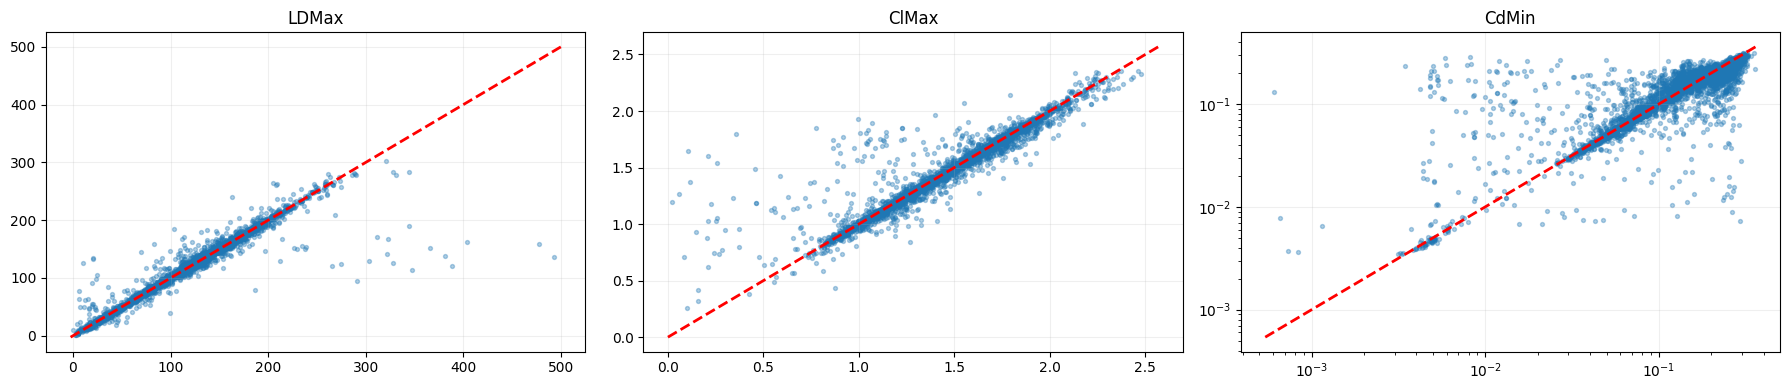


Saved Forward v3 artifacts
Variant screen   : /kaggle/working/aeroml_forward_v3/aeroml_xfoil_forward_v3_variant_screen.csv
Seed metrics     : /kaggle/working/aeroml_forward_v3/aeroml_xfoil_forward_v3_seed_metrics.csv
Ensemble metrics : /kaggle/working/aeroml_forward_v3/aeroml_xfoil_forward_v3_ensemble_metrics.json
Ensemble preds   : /kaggle/working/aeroml_forward_v3/aeroml_xfoil_forward_v3_ensemble_predictions.csv


In [6]:
final_runs = []
for seed in FINAL_SEEDS:
    print("\n" + "=" * 72)
    print(f"Training final v3 champion | variant={best_variant} | seed={seed}")
    print("=" * 72)
    final_runs.append(
        train_variant(
            seed=seed,
            variant_name=best_variant,
            save_model=True,
            model_tag=f"{best_variant}_seed{seed}",
        )
    )

seed_metric_rows = []
for run in final_runs:
    seed_metric_rows.append(
        {
            "seed": run["seed"],
            "variant": run["variant"],
            "best_val_loss": run["best_val_loss"],
            "LDMax_R2": run["test_metrics"]["LDMax"]["R2"],
            "ClMax_R2": run["test_metrics"]["ClMax"]["R2"],
            "CdMin_R2": run["test_metrics"]["CdMin"]["R2"],
            "CdMin_MAE": run["test_metrics"]["CdMin"]["MAE"],
            "CdMin_MedianAE": run["test_metrics"]["CdMin"]["MedianAE"],
            "CdMin_Within25Pct": run["test_metrics"]["CdMin"]["Within25Pct"],
            "LowDrag_CdMin_Within25Pct": run["low_drag_metrics"]["CdMin"]["Within25Pct"],
        }
    )
seed_metrics_df = common.pd.DataFrame(seed_metric_rows).sort_values("best_val_loss").reset_index(drop=True)
seed_metrics_df.to_csv(V3_SEED_METRICS_PATH, index=False)
print("\nChampion variant seed metrics")
print(seed_metrics_df.to_string(index=False))

best_run = min(final_runs, key=lambda item: item["best_val_loss"])
ensemble_ld = common.np.mean(common.np.stack([run["test_pred"][:, 0] for run in final_runs], axis=0), axis=0)
ensemble_cl = common.np.mean(common.np.stack([run["test_pred"][:, 1] for run in final_runs], axis=0), axis=0)
ensemble_cd = common.np.exp(common.np.mean(common.np.stack([run["test_cd_log"] for run in final_runs], axis=0), axis=0))
ensemble_pred = common.np.column_stack([ensemble_ld, ensemble_cl, ensemble_cd])

ensemble_metrics = common.collect_metrics(y_test_raw, ensemble_pred)
low_drag_mask = y_test_raw[:, 2] <= common.np.quantile(y_train_raw[:, 2], 0.25)
low_drag_metrics = common.collect_metrics(y_test_raw[low_drag_mask], ensemble_pred[low_drag_mask])

stability = {
    "LDMax_R2_std": float(seed_metrics_df["LDMax_R2"].std(ddof=0)),
    "ClMax_R2_std": float(seed_metrics_df["ClMax_R2"].std(ddof=0)),
    "CdMin_R2_std": float(seed_metrics_df["CdMin_R2"].std(ddof=0)),
    "LowDrag_CdMin_Within25Pct_min": float(seed_metrics_df["LowDrag_CdMin_Within25Pct"].min()),
}
stability_ok = (
    stability["LDMax_R2_std"] <= 0.02
    and stability["ClMax_R2_std"] <= 0.02
    and stability["CdMin_R2_std"] <= 0.03
    and stability["LowDrag_CdMin_Within25Pct_min"] >= 0.75
)
gate_primary = (
    ensemble_metrics["LDMax"]["R2"] >= 0.90
    and ensemble_metrics["ClMax"]["R2"] >= 0.86
    and (
        ensemble_metrics["CdMin"]["R2"] >= 0.75
        or (
            ensemble_metrics["CdMin"]["MedianAE"] <= 0.012
            and ensemble_metrics["CdMin"]["Within25Pct"] >= 0.80
        )
    )
)

baseline_metrics = json.loads(BASELINE_METRICS_PATH.read_text(encoding="utf-8"))["metrics"] if BASELINE_METRICS_PATH.exists() else None

ensemble_frame = meta.iloc[test_idx][["example_name", "fingerprint", "Re", "Mach", "duplicate_rows", "duplicate_names"]].copy()
ensemble_frame["LDMax_true"] = y_test_raw[:, 0]
ensemble_frame["LDMax_pred"] = ensemble_pred[:, 0]
ensemble_frame["ClMax_true"] = y_test_raw[:, 1]
ensemble_frame["ClMax_pred"] = ensemble_pred[:, 1]
ensemble_frame["CdMin_true"] = y_test_raw[:, 2]
ensemble_frame["CdMin_pred"] = ensemble_pred[:, 2]
ensemble_frame.to_csv(V3_ENSEMBLE_PRED_PATH, index=False)

common.write_json(
    V3_ENSEMBLE_METRICS_PATH,
    {
        "chosen_variant": best_variant,
        "baseline_metrics": baseline_metrics,
        "best_seed": int(best_run["seed"]),
        "best_seed_metrics": best_run["test_metrics"],
        "ensemble_metrics": ensemble_metrics,
        "low_drag_ensemble_metrics": low_drag_metrics,
        "stability": stability,
        "gate_primary": bool(gate_primary),
        "stability_ok": bool(stability_ok),
        "gate_pass": bool(gate_primary and stability_ok),
    },
)

print("\nChosen variant:", best_variant)
print("Best single seed:", best_run["seed"])
print("Ensemble metrics:", json.dumps(ensemble_metrics, indent=2))
print("Low-drag ensemble metrics:", json.dumps(low_drag_metrics, indent=2))
print("Stability:", json.dumps(stability, indent=2))
print("Inverse-design gate passed:", gate_primary and stability_ok)

if baseline_metrics is not None:
    compare_df = common.pd.DataFrame(
        [
            {
                "target": target,
                "baseline_R2": baseline_metrics[target]["R2"],
                "v3_ensemble_R2": ensemble_metrics[target]["R2"],
                "delta_R2": ensemble_metrics[target]["R2"] - baseline_metrics[target]["R2"],
                "baseline_MAE": baseline_metrics[target]["MAE"],
                "v3_ensemble_MAE": ensemble_metrics[target]["MAE"],
                "delta_MAE": ensemble_metrics[target]["MAE"] - baseline_metrics[target]["MAE"],
            }
            for target in ["LDMax", "ClMax", "CdMin"]
        ]
    )
    print("\nBaseline v1 vs Forward v3 ensemble")
    print(compare_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, idx, title in zip(axes, [0, 1, 2], ["LDMax", "ClMax", "CdMin"]):
    plot_idx = common.np.random.choice(len(y_test_raw), min(4000, len(y_test_raw)), replace=False)
    ax.scatter(y_test_raw[plot_idx, idx], ensemble_pred[plot_idx, idx], s=8, alpha=0.35)
    lo = min(y_test_raw[:, idx].min(), ensemble_pred[:, idx].min())
    hi = max(y_test_raw[:, idx].max(), ensemble_pred[:, idx].max())
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=2)
    ax.set_title(title)
    ax.grid(alpha=0.2)
    if title == "CdMin":
        ax.set_xscale("log")
        ax.set_yscale("log")
plt.tight_layout()
plt.show()

print("\nSaved Forward v3 artifacts")
print("=" * 72)
print("Variant screen   :", V3_SCREEN_PATH)
print("Seed metrics     :", V3_SEED_METRICS_PATH)
print("Ensemble metrics :", V3_ENSEMBLE_METRICS_PATH)
print("Ensemble preds   :", V3_ENSEMBLE_PRED_PATH)
